In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import kagglehub
import os
import folium
import requests

In [57]:
path = kagglehub.dataset_download("ariyoomotade/netflix-data-cleaning-analysis-and-visualization")
print(os.listdir(path))

['netflix1.csv']


In [58]:
csv_path = os.path.join(path, "netflix1.csv")
df = pd.read_csv(csv_path)
df.tail()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
8785,s8797,TV Show,Yunus Emre,Not Given,Turkey,1/17/2017,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8786,s8798,TV Show,Zak Storm,Not Given,United States,9/13/2018,2016,TV-Y7,3 Seasons,Kids' TV
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,12/15/2016,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ..."
8788,s8784,TV Show,Yoko,Not Given,Pakistan,6/23/2018,2016,TV-Y,1 Season,Kids' TV
8789,s8786,TV Show,YOM,Not Given,Pakistan,6/7/2018,2016,TV-Y7,1 Season,Kids' TV


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [60]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [61]:
df = df.rename(columns={'date_added':'date'})
df['date'] = pd.to_datetime(df.date)

In [63]:
df['country'].unique()

array(['United States', 'France', 'Brazil', 'United Kingdom', 'India',
       'Germany', 'Pakistan', 'Not Given', 'China', 'South Africa',
       'Japan', 'Nigeria', 'Spain', 'Philippines', 'Australia',
       'Argentina', 'Canada', 'Hong Kong', 'Italy', 'New Zealand',
       'Egypt', 'Colombia', 'Mexico', 'Belgium', 'Switzerland', 'Taiwan',
       'Bulgaria', 'Poland', 'South Korea', 'Saudi Arabia', 'Thailand',
       'Indonesia', 'Kuwait', 'Malaysia', 'Vietnam', 'Lebanon', 'Romania',
       'Syria', 'United Arab Emirates', 'Sweden', 'Mauritius', 'Austria',
       'Turkey', 'Czech Republic', 'Cameroon', 'Netherlands', 'Ireland',
       'Russia', 'Kenya', 'Chile', 'Uruguay', 'Bangladesh', 'Portugal',
       'Hungary', 'Norway', 'Singapore', 'Iceland', 'Serbia', 'Namibia',
       'Peru', 'Mozambique', 'Ghana', 'Zimbabwe', 'Israel', 'Finland',
       'Denmark', 'Paraguay', 'Cambodia', 'Georgia', 'Soviet Union',
       'Greece', 'West Germany', 'Iran', 'Venezuela', 'Slovenia',
       'Gua

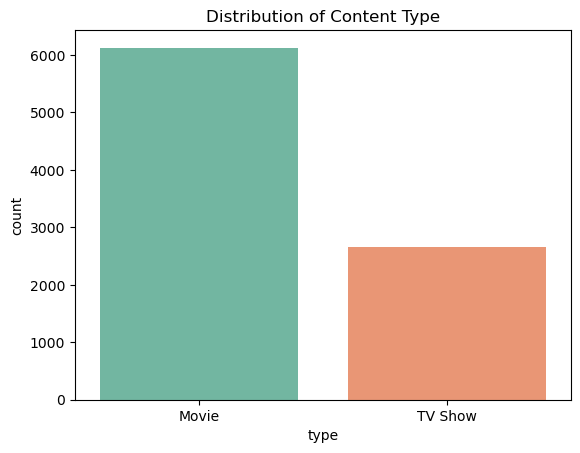

In [79]:
sns.countplot(x='type', data=df, hue='type', palette='Set2')
plt.title('Distribution of Content Type')
plt.show()

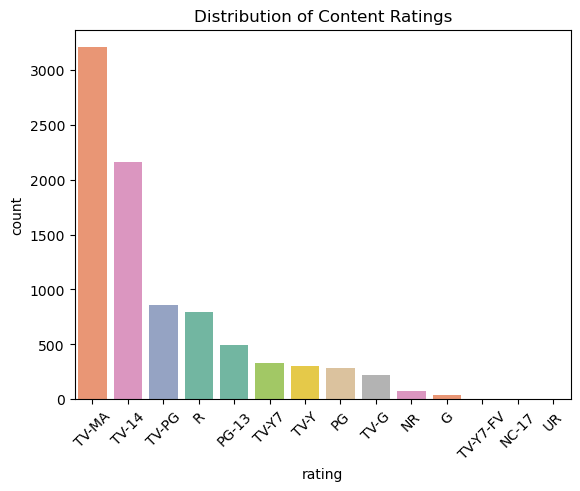

In [80]:
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, hue='rating', palette='Set2')
plt.title('Distribution of Content Ratings')
plt.xticks(rotation=45)
plt.show()

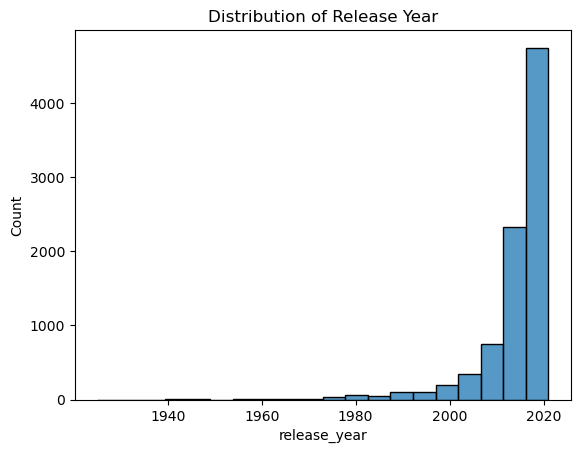

In [81]:
sns.histplot(df['release_year'], bins=20)
plt.title('Distribution of Release Year')
plt.show()

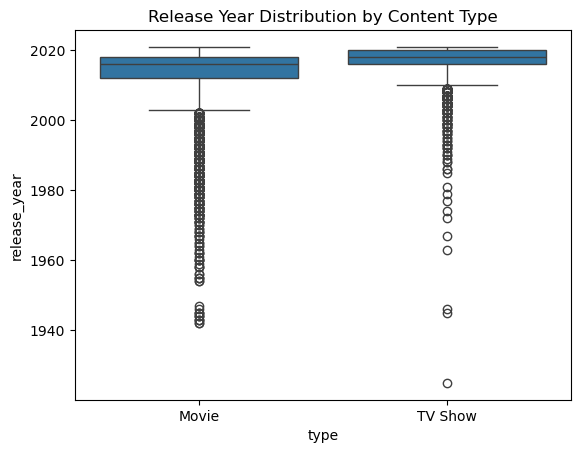

In [78]:
sns.boxplot(x='type', y='release_year', data=df)
plt.title('Release Year Distribution by Content Type')
plt.show()

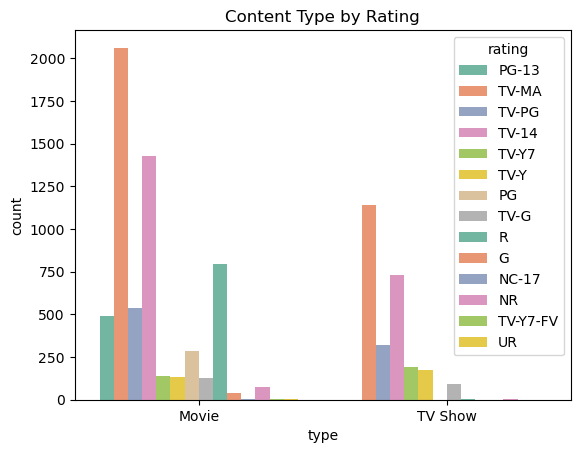

In [82]:
sns.countplot(x='type', data=df, hue='rating', palette='Set2')
plt.title('Content Type by Rating')
plt.show()

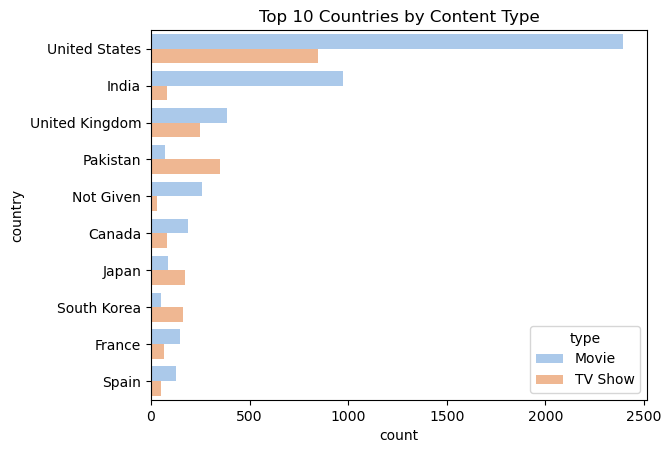

In [83]:
top10_countries = df['country'].value_counts().index[:10]
sns.countplot(y='country', hue='type', data=df[df['country'].isin(top10_countries)], order=top10_countries, palette='pastel')
plt.title('Top 10 Countries by Content Type')
plt.show()

In [69]:
country_counts = df['country'].value_counts().reset_index()
country_counts.columns = ['country','count']

In [70]:
url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json"
geo_json_data = requests.get(url).json()

country_names = [feature['properties']['name'] for feature in geo_json_data['features']]

In [84]:
geo_names = set(country_names)

In [85]:
country_counts['country'] = country_counts['country'].replace({
    'United States': 'United States of America',
    'West Germany': 'Germany',
    'Soviet Union': 'Russia'})

In [86]:
world_map = folium.Map(location=[0,0], zoom_start=2)

folium.Choropleth(
    geo_data="https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json",
    data=country_counts,
    columns=['country','count'],
    key_on='feature.properties.name',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Number of Netflix Titles').add_to(world_map)

world_map